# Estimating the Implied Volatility Surface

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf

from bsm import bsm_price, implied_vol, vega
from data import get_bsm_opt_df, hist_vol, add_bsm_baseline, add_implied_vol, add_vega
from models import fit_models, add_model_predictions
from plots import (set_style, plot_two_panel_scatter, plot_surface_pair,
                   plot_mispricing_grid, plot_put_call_parity)

set_style()

In [3]:
TICKER = 'SPY'

r = 0.03808   # risk-free rate (3-month T-Bill)
q = 0.0097    # SPY trailing twelve-month dividend yield

In [4]:
print(yf.Ticker(TICKER).options)

('2026-08-17', '2026-08-18', '2026-08-19', '2026-08-20', '2026-08-21', '2026-08-28', '2026-08-31', '2026-09-04', '2026-09-11', '2026-09-18', '2026-09-25', '2026-09-30', '2026-10-16', '2026-10-30', '2026-11-20', '2026-11-30', '2026-12-18', '2026-12-31', '2027-01-15', '2027-01-29', '2027-03-19', '2027-03-31', '2027-06-17', '2027-06-30', '2027-09-17', '2027-12-17', '2028-01-21', '2028-06-16', '2028-12-15')


In [ ]:
MATURITIES = [
    '2026-08-28', '2026-09-18', '2026-10-16',
    '2026-11-20', '2026-12-18', '2027-01-15',
    '2027-06-17', '2027-12-17',
]

In [5]:
sigma_hist = hist_vol(TICKER, period='3mo')
print(f'Historical volatility (3mo): {sigma_hist:.4f}')

Historical volatility (3mo): 0.1379


In [6]:
def build_dataset(opt_type):
    """Full pipeline for one option type: download, filter, price, solve IV, add vega."""
    df = get_bsm_opt_df(TICKER, MATURITIES, opt_type)
    df = add_bsm_baseline(df, r=r, q=q, sigma_hist=sigma_hist, opt_type=opt_type)
    df = add_implied_vol(df, r=r, q=q, opt_type=opt_type)
    df = add_vega(df, r=r, q=q)
    return df

calls = build_dataset('call')
puts = build_dataset('put')

print(f'calls: {len(calls)} rows | puts: {len(puts)} rows')

calls: 371 rows | puts: 482 rows


In [7]:
print('CALLS')
print(calls['expirationDate'].value_counts().sort_index())
print()
print('PUTS')
print(puts['expirationDate'].value_counts().sort_index())

CALLS
expirationDate
2026-08-28    51
2026-09-18    77
2026-10-16    50
2026-11-20    28
2026-12-18    34
2027-01-15    41
2027-06-17    57
2027-12-17    33
Name: count, dtype: int64

PUTS
expirationDate
2026-08-28     50
2026-09-18    121
2026-10-16     75
2026-11-20     48
2026-12-18     54
2027-01-15     51
2027-06-17     53
2027-12-17     30
Name: count, dtype: int64


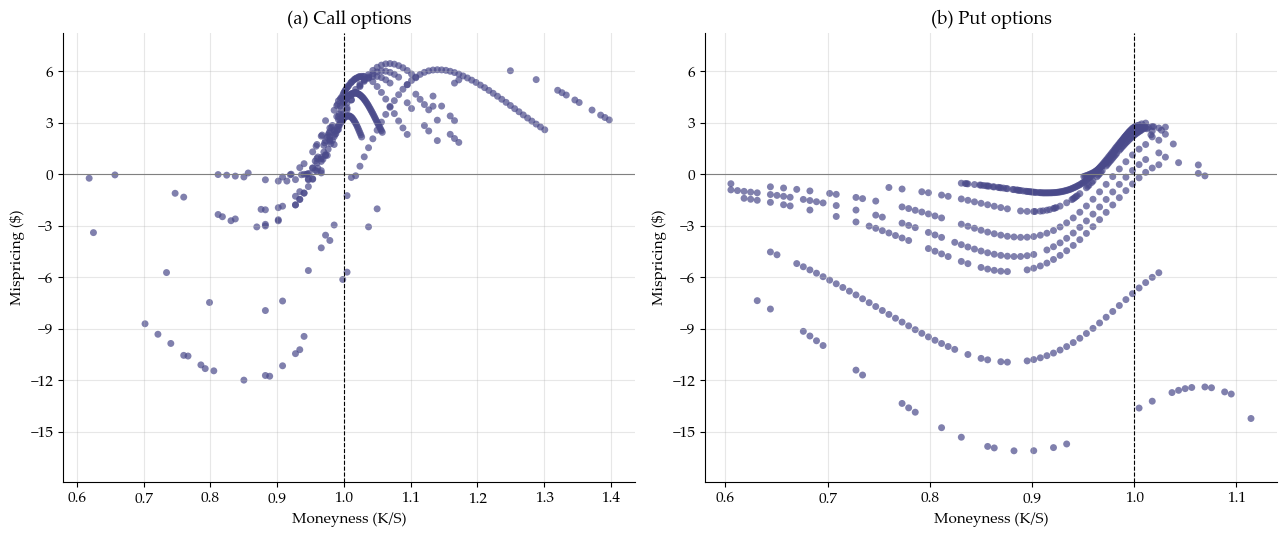

In [8]:
plot_two_panel_scatter(calls, puts, 'bsmDifference', 'Mispricing ($)',
                       hline=0, integer_yticks=True,
                       filename='figures/bsmMispricingAbs.png')

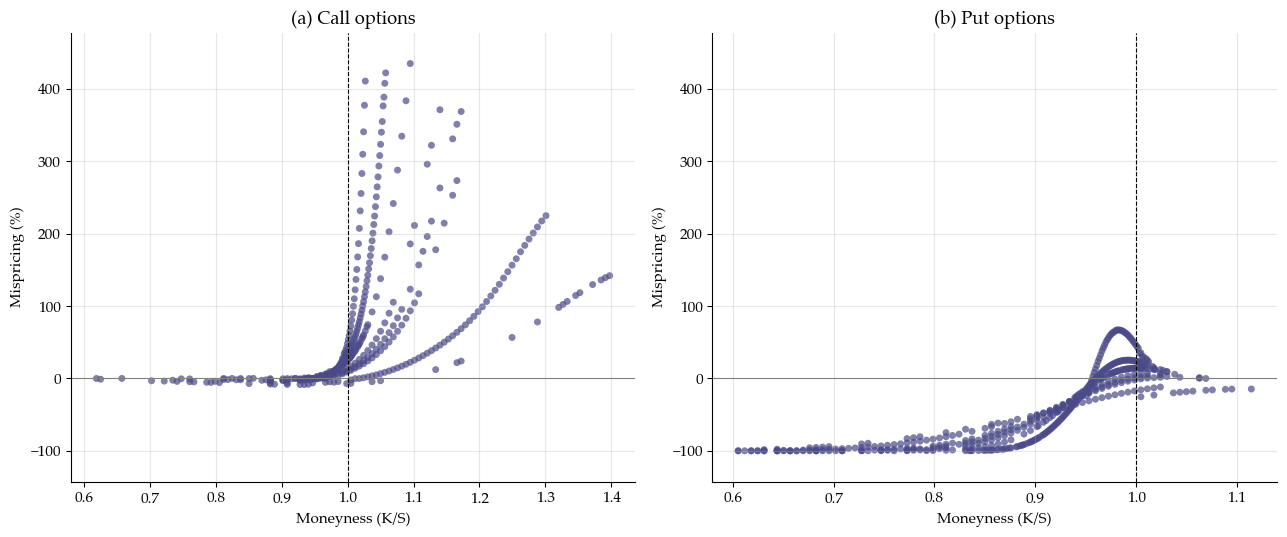

In [9]:
plot_two_panel_scatter(calls, puts, 'pctError', 'Mispricing (%)',
                       hline=0, filename='figures/bsmMispricingPct.png')

In [10]:
for name, df in [('calls', calls), ('puts', puts)]:
    print(f"{name}: max |absolute| = {df['bsmDifference'].abs().max():.2f} "
          f"| max |percentage| = {df['pctError'].abs().max():.1f}%")

calls: max |absolute| = 11.99 | max |percentage| = 435.0%
puts: max |absolute| = 16.11 | max |percentage| = 100.0%


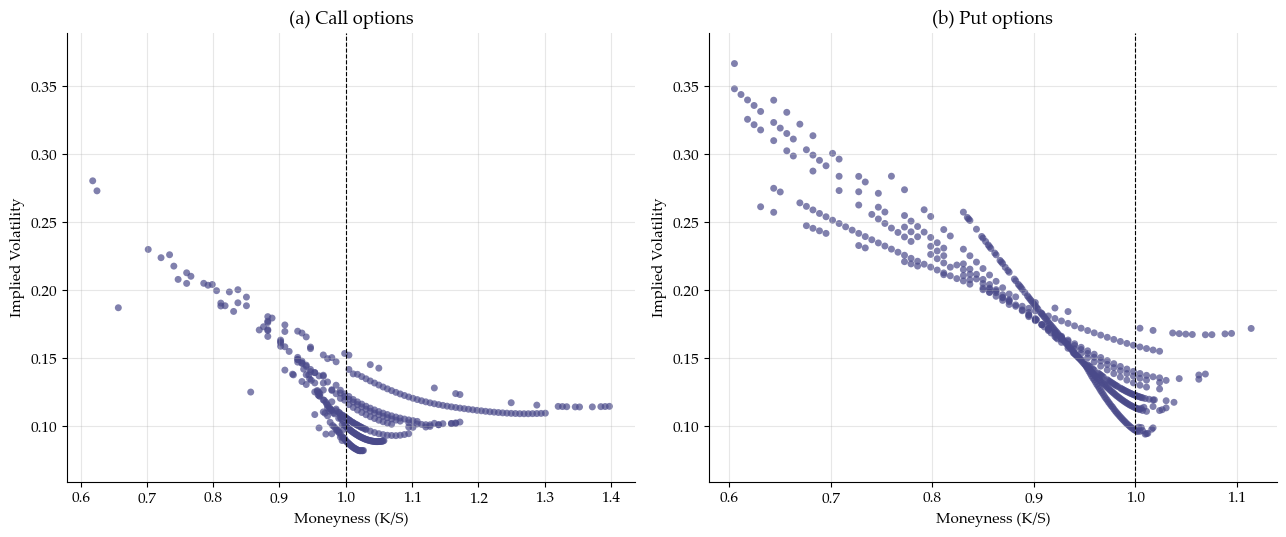

In [11]:
plot_two_panel_scatter(calls, puts, 'impliedVol', 'Implied Volatility',
                       filename='figures/ivSkew.png')

In [12]:
call_models = fit_models(calls)
put_models = fit_models(puts)

rmse_table = pd.DataFrame({
    'Call RMSE': [call_models['ridge_rmse'], call_models['rf_rmse']],
    'Put RMSE':  [put_models['ridge_rmse'],  put_models['rf_rmse']],
}, index=['Polynomial regression', 'Random Forest'])

rmse_table.round(5)

,Call RMSE,Put RMSE
Polynomial regression,0.00829,0.00595
Random Forest,0.00632,0.00462


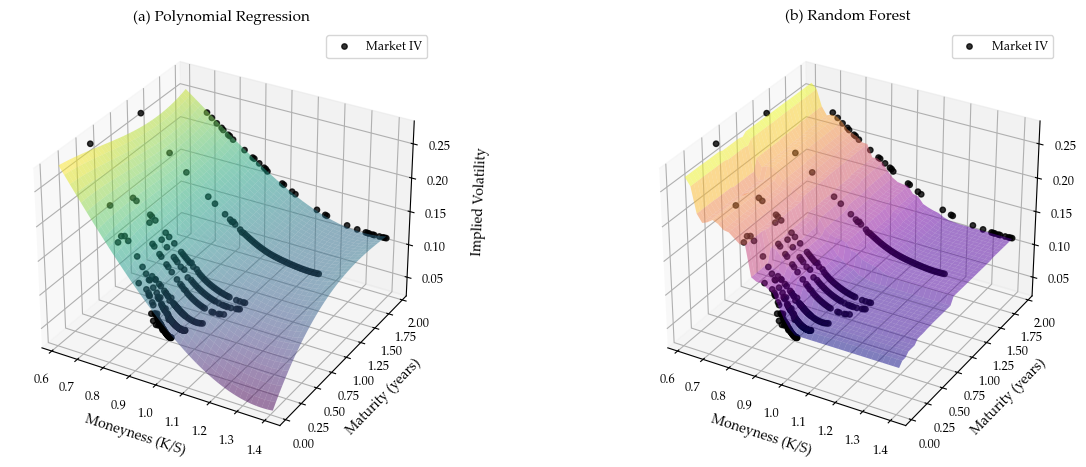

In [13]:
plot_surface_pair(calls, call_models, filename='figures/volSurfaceCall.png')

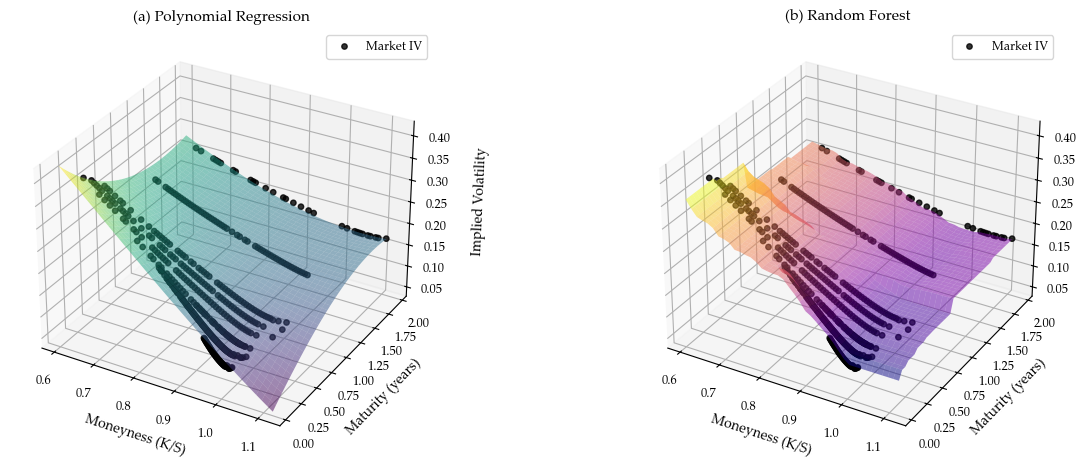

In [14]:
plot_surface_pair(puts, put_models, filename='figures/volSurfacePut.png')

In [15]:
calls = add_model_predictions(calls, call_models, r=r, q=q, opt_type='call')
puts = add_model_predictions(puts, put_models, r=r, q=q, opt_type='put')

cols = ['moneyness', 'midPrice', 'impliedVol', 'impliedVolRidge', 'impliedVolRf',
        'bsmDifferenceRidge', 'bsmDifferenceRf']
calls[cols].head()

,moneyness,midPrice,impliedVol,impliedVolRidge,impliedVolRf,bsmDifferenceRidge,bsmDifferenceRf
0,0.936445,50.425,0.141968,0.121462,0.140003,-0.090,-0.012
1,0.944174,44.525,0.137732,0.118165,0.136048,-0.140,-0.015
2,0.945462,43.525,0.134819,0.117620,0.135555,-0.129,0.007
3,0.946750,42.865,0.157067,0.117075,0.135268,-0.456,-0.305
4,0.948038,41.575,0.133761,0.116532,0.134663,-0.152,0.011


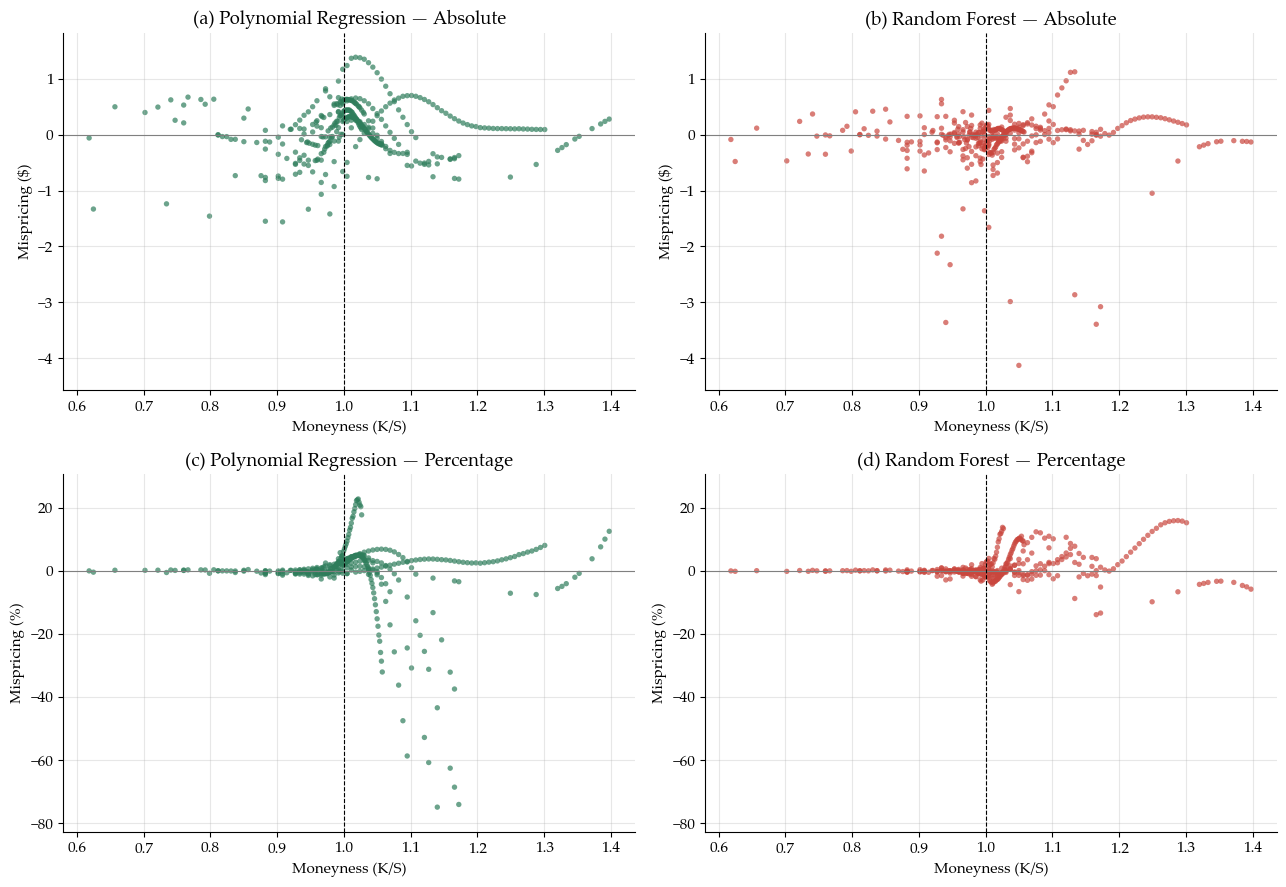

In [16]:
plot_mispricing_grid(calls, filename='figures/pricingErrorCall.png')

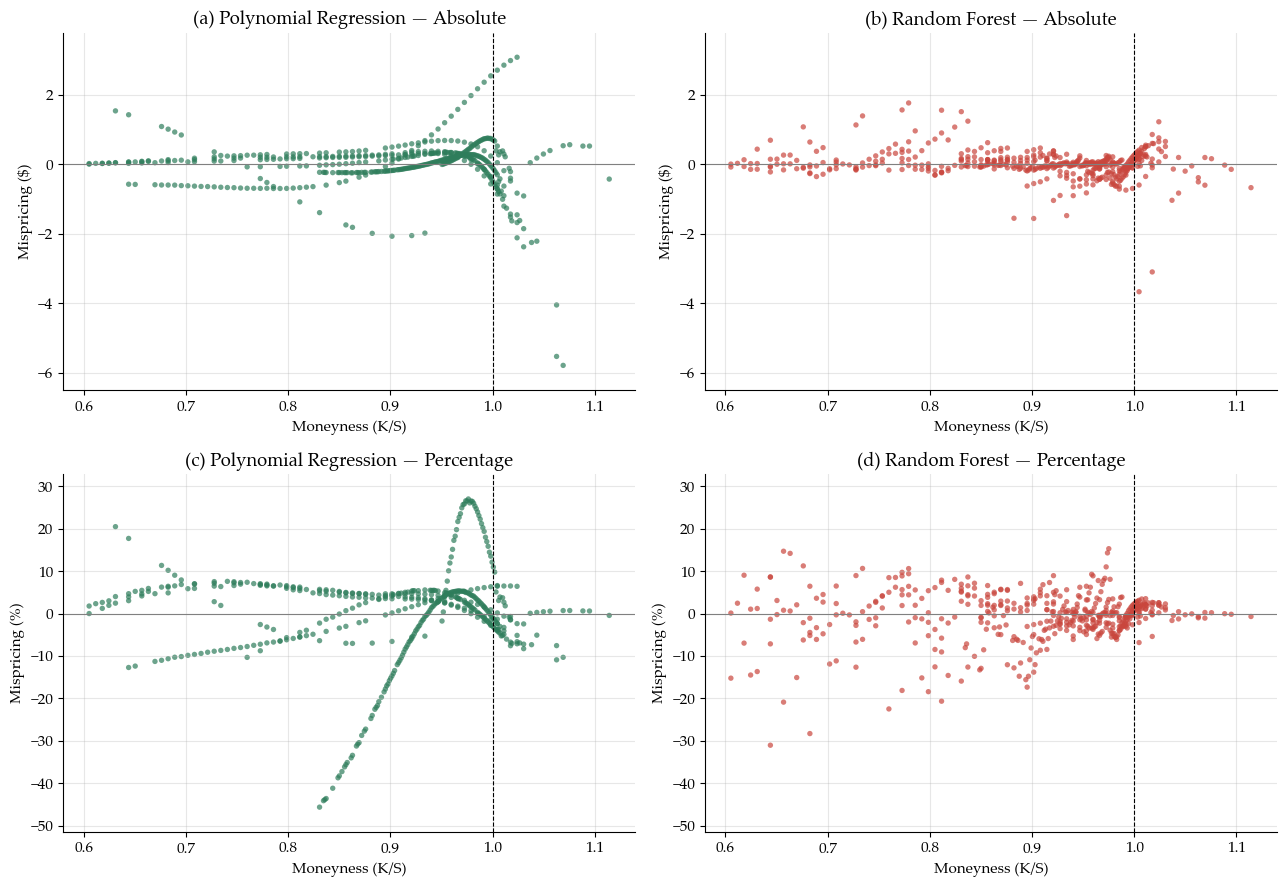

In [17]:
plot_mispricing_grid(puts, filename='figures/pricingErrorPut.png')

In [18]:
for name, df in [('calls', calls), ('puts', puts)]:
    print(f"{name}: baseline {df['pctError'].abs().max():6.1f}%  ->  "
          f"ridge {df['pctErrorRidge'].abs().max():5.1f}%  |  "
          f"rf {df['pctErrorRf'].abs().max():5.1f}%")

calls: baseline  435.0%  ->  ridge  74.9%  |  rf  15.9%
puts: baseline  100.0%  ->  ridge  45.6%  |  rf  31.0%


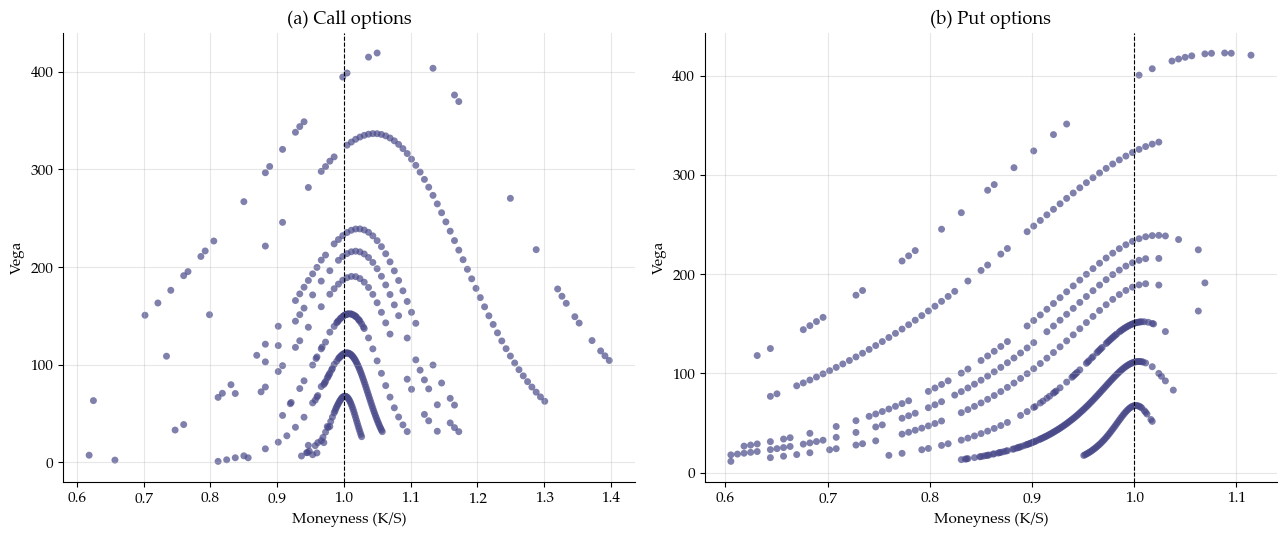

In [19]:
plot_two_panel_scatter(calls, puts, 'vega', 'Vega',
                       shared_scale=False, filename='figures/vega.png')

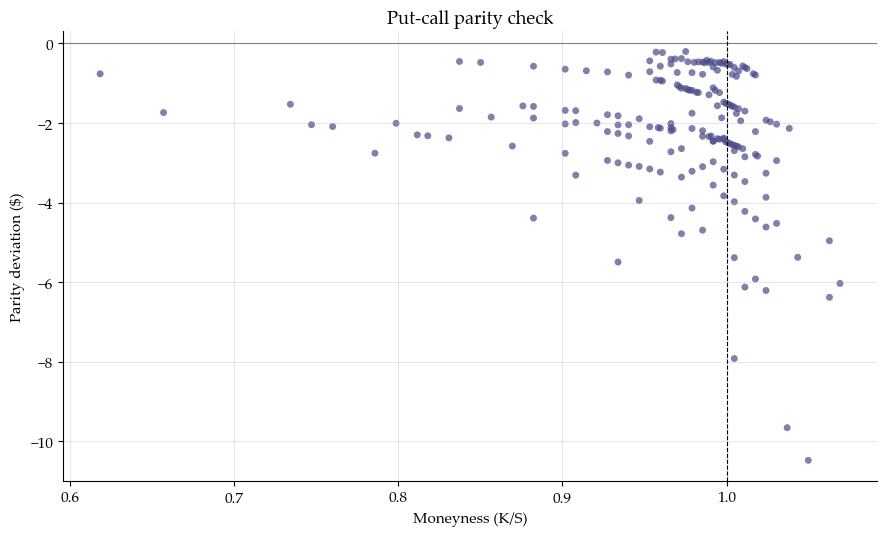

count    185.000
mean      -2.186
std        1.659
min      -10.476
25%       -2.757
50%       -2.006
75%       -0.826
max       -0.203
Name: parityError, dtype: float64

In [20]:
parity = plot_put_call_parity(calls, puts, r=r, q=q, filename='figures/parity.png')
parity['parityError'].describe().round(3)

In [21]:
from datetime import date

stamp = date.today().isoformat()
calls.to_parquet(f'spy_calls_{stamp}.parquet', index=False)
puts.to_parquet(f'spy_puts_{stamp}.parquet', index=False)
print(f'saved: spy_calls_{stamp}.parquet, spy_puts_{stamp}.parquet')

saved: data/spy_calls_2026-08-15.parquet, data/spy_puts_2026-08-15.parquet
